## Step 1: Load each CSV

In [1]:
import pandas as pd

categories = pd.read_csv('categories.csv')
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
order_details = pd.read_csv('order_details.csv')
products = pd.read_csv('products.csv')

## Step 2: Look at each one individually

In [2]:
for name, df in [('categories', categories), ('customers', customers),
                ('orders', orders), ('order_details', order_details),
                ('products', products)]:
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print(df.head())
    print()

--- categories ---
Shape: (10, 2)
  CategoryID    CategoryName
0  CTGRY0001  Meat & Poultry
1  CTGRY0002    Dairy & Eggs
2  CTGRY0003         Produce
3  CTGRY0004       Beverages
4  CTGRY0005          Bakery

--- customers ---
Shape: (1000, 7)
  CustomerID  Gender  Age      City   Region CustomerSegment  SignUpDate
0  CSTMR0001    Male   29  Istanbul  Marmara        Standard  2020-04-13
1  CSTMR0002   Other   40  Istanbul  Marmara        Standard  2020-04-08
2  CSTMR0003  Female   36     Bursa  Marmara         Premium  2022-08-14
3  CSTMR0004    Male   18  Istanbul  Marmara         Premium  2022-03-26
4  CSTMR0005    Male   43     Izmir   Aegean         Premium  2021-04-04

--- orders ---
Shape: (10000, 4)
    OrderID CustomerID   OrderDate OrderTime
0  ORD00001  CSTMR0983  2021-04-10  12:53:24
1  ORD00002  CSTMR0703  2024-04-21  22:08:16
2  ORD00003  CSTMR0920  2022-10-27  10:21:26
3  ORD00004  CSTMR0158  2025-11-07  22:24:27
4  ORD00005  CSTMR0834  2021-09-05  13:23:16

--- order_det

## Step 3: Also open the .db file -- this uses your SQL knowledge directly

In [3]:
import sqlite3

# This opens a connection to the .db file (similar to connecting to MySQL)
conn = sqlite3.connect('retail_store.db')

In [4]:
# See what tables exist inside it
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';", conn
)
print(tables)

            name
0     categories
1       products
2      customers
3         orders
4  order_details


### Step explanation:

- **sqlite3.connect('retail_store.db')** -- this opens a connection to the .db file, similar to how you'd connect to MySQL with a username/password, except SQLite databases are just a single file on disk -no server, no login needed. Conn is now your "pipe" to that database.
- **sqlite_master** -- this is a special built-in table that every SQLite database automatically has. It stores metadata about listing of every table, index, and view inside it.
- **pd.read_sql(...)** -- instead of manually running the query and looping through results, this pandas functiion runs the SQL query and immediately hands you back the result as a dataframe -- combining SQL and pandas in one step

## Step 4: Peek at each table's structure using SQL

In [5]:
query = """
SELECT *
FROM products
LIMIT 10, 5;
"""

pd.read_sql(query, conn)

,ProductID,ProductName,CategoryID
0,PRDCT0011,ABC's Whole Milk,CTGRY0002
1,PRDCT0012,XYZ's Yogurt,CTGRY0002
2,PRDCT0013,KLM's Cheddar Cheese,CTGRY0002
3,PRDCT0014,ABC's Salted Butter,CTGRY0002
4,PRDCT0015,XYZ's Cottage Cheese,CTGRY0002


### Step explained  

- **SELECT * FROM orders** -- standard SQL: grab every column from the orders table.
- **LIMIT 5** -- only return 5 rows, just to peek at the structure without pulling the entire table.
- **pd.read_sql(query, conn)** -- runs the query against the same connection from Step 3, and returns it as a pandas dataframe you can view/manipulate normally.

**Reason:** Once we know a table's name, we look inside it to see its actual columns and sample data -- this tells us how it might connect to the CSV files you already loaded (e.g,**if orders has a customer_id** column, that's the link to your **customers.csv**)

In [9]:
order_details.head()

,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
0,ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,NaN
1,ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,NaN
2,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,NaN
3,ORD00003,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,NaN
4,ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,NaN


In [7]:
query = """
SELECT *
FROM Customers
LIMIT 5;
"""
pd.read_sql(query, conn)

,CustomerID,Gender,Age,City,Region,CustomerSegment,SignUpDate
0,CSTMR0001,Male,29,Istanbul,Marmara,Standard,2020-04-13
1,CSTMR0002,Other,40,Istanbul,Marmara,Standard,2020-04-08
2,CSTMR0003,Female,36,Bursa,Marmara,Premium,2022-08-14
3,CSTMR0004,Male,18,Istanbul,Marmara,Premium,2022-03-26
4,CSTMR0005,Male,43,Izmir,Aegean,Premium,2021-04-04


In [11]:
customers['City'].value_counts()

City
Istanbul     364
Ankara       155
Izmir        134
Bursa        111
Kocaeli       91
Aydin         44
Antalya       43
Eskisehir     32
Adana         17
Trabzon        9
Name: count, dtype: int64

In [18]:
orders.merge(customers, on='CustomerID').merge(order_details, on='OrderID').head()

,OrderID,CustomerID,OrderDate,OrderTime,Gender,Age,City,Region,CustomerSegment,SignUpDate,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
0,ORD00001,CSTMR0983,2021-04-10,12:53:24,Male,59,Istanbul,Marmara,Standard,2020-10-20,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,NaN
1,ORD00002,CSTMR0703,2024-04-21,22:08:16,Female,47,Istanbul,Marmara,Standard,2020-11-06,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,NaN
2,ORD00002,CSTMR0703,2024-04-21,22:08:16,Female,47,Istanbul,Marmara,Standard,2020-11-06,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,NaN
3,ORD00003,CSTMR0920,2022-10-27,10:21:26,Male,34,Ankara,Central Anatolia,Standard,2022-04-15,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,NaN
4,ORD00004,CSTMR0158,2025-11-07,22:24:27,Male,35,Ankara,Central Anatolia,VIP,2021-01-08,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,NaN


In [19]:
query = """
SELECT o.OrderID, c.CustomerID, c.City, c.CustomerSegment
FROM orders o
JOIN customers c ON o.CustomerID = c.CustomerID
LIMIT 10;
"""

pd.read_sql(query, conn)

,OrderID,CustomerID,City,CustomerSegment
0,ORD00001,CSTMR0983,Istanbul,Standard
1,ORD00002,CSTMR0703,Istanbul,Standard
2,ORD00003,CSTMR0920,Ankara,Standard
3,ORD00004,CSTMR0158,Ankara,VIP
4,ORD00005,CSTMR0834,Istanbul,VIP
5,ORD00006,CSTMR0336,Ankara,Standard
6,ORD00007,CSTMR0166,Aydin,Premium
7,ORD00008,CSTMR0102,Kocaeli,Premium
8,ORD00009,CSTMR0271,Bursa,Standard
9,ORD00010,CSTMR0678,Ankara,Standard


So the relationship chain is:  
customers -> orders -> order_details -> products -> categories

## Step 5: Look inside order_details (from the database)

In [20]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('retail_store.db')

In [27]:
query = """
SELECT *
FROM Order_Details
LIMIT 5;
"""
pd.read_sql(query, conn)

,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
0,ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,None
1,ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,None
2,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,None
3,ORD00003,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,None
4,ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,None


- **What this does:** connects to **retail_store.db**, and pull the first 5 rows from the order_detaills table so we can see its columns and sample data. 

Let's break down what each column means, since this table is the heart of your dataset (it's where the actual transactions live).

### Understanding order_details
- **OrderID** ->	Which order this item belongs to (links to orders table)
- **ProductID** ->	Which product was bought (links to products table)
- **Quantity** ->	How many units were bought
- **UnitCost** ->	What it cost the store to acquire one unit (their cost price)
- **UnitPrice** ->	What the customer was charged per unit (selling price)
- **DiscountRate** ->	Any discount applied (0.05 = 5% off)
- **IsReturned** ->	0 = not returned, 1 = returned
- **ReturnDate / ReturnTime** ->	When it was returned (notice 9999-12-31 — this is a placeholder meaning "not returned," not a real date)
- **ReturnReason** ->	Why it was returned (None here, since nothing was returned in these rows)

**One important thing to notice:** each row here is one **product line** within an order, not one order, ie OrderID **ORD00002** - it appears twice, because that single order contained two different products.

In [30]:
## Let's retrieve the order details made by ORD00002
query = """
SELECT *
FROM Order_details
WHERE OrderID = 'ORD00002';
"""
pd.read_sql(query, conn)

,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
0,ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,None
1,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,None


### Step 6: First JOIN - connect orders to customers

In [60]:
query = """
SELECT 
    o.OrderID,
    c.CustomerID,
    o.OrderDate,
    c.CustomerSegment,
    od.Quantity,
    od.UnitPrice,
    (od.Quantity * od.UnitPrice) as TotalPaid,
    p.ProductName
FROM orders o
JOIN customers c ON o.CustomerID = c.CustomerID
JOIN order_details od ON o.OrderID = od.OrderID
JOIN products p ON od.ProductID = p.ProductID
WHERE o.CustomerID = 'CSTMR0703'
ORDER BY o.OrderDate DESC
LIMIT 5;
"""
# orders made by one customer
pd.read_sql(query, conn)

,OrderID,CustomerID,OrderDate,CustomerSegment,Quantity,UnitPrice,TotalPaid,ProductName
0,ORD08340,CSTMR0703,2025-10-18,Standard,10,10.34,103.40,YZA's Daily Shampoo
1,ORD01708,CSTMR0703,2025-07-20,Standard,2,8.35,16.70,ABC's Organic Carrots
2,ORD01708,CSTMR0703,2025-07-20,Standard,1,22.74,22.74,YZA's Liquid Hand Soap
3,ORD01708,CSTMR0703,2025-07-20,Standard,2,10.34,20.68,YZA's Daily Shampoo
4,ORD01708,CSTMR0703,2025-07-20,Standard,3,9.47,28.41,DEF's Sunscreen SPF 50


**Why this matters:** on its own, orders only shows you a CustomerID code like CSTMR0703 - meaningless without context. This join lets you see where that customer is from and other details about that customer, right alongside their order.  

The real power is this: you can now group and filter by things that weren't originally attached to orders at all.  

For example, with this joined view you could now ask:
- "Which city generate the most orders"
- "Do VIP customers order more often than Standard customers"
- "Is there a region where sales are growing or shrinking?"

None of those questions were answerabel from orders alone - you needed customers' columns attached to make them askable. That's the core idea: joining doesn't just add columns for decoration, it unlocks entirely new questions you can ask of the data.

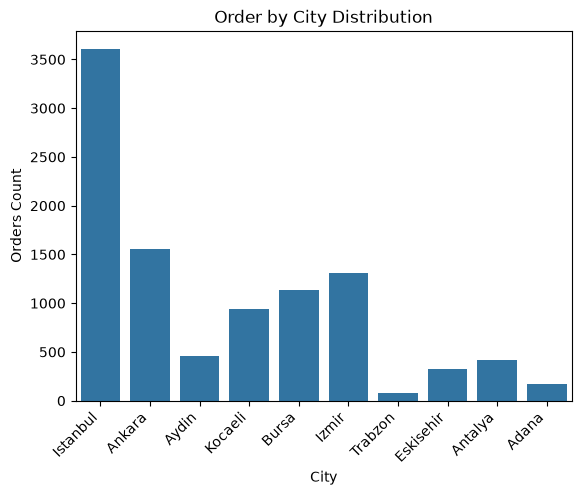

In [104]:
customer_orders = orders.merge(customers, on='CustomerID')

import matplotlib.pyplot as plt
import seaborn as sns

# Which city generated the most orders?
sns.countplot(data=customer_orders, x='City')
plt.title('Order by City Distribution')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Orders Count')
plt.xlabel('City')
plt.show()

In [62]:
# Do VIP customers order more often than Standard customers?
customer_orders['CustomerSegment'].value_counts()

CustomerSegment
Standard    6025
Premium     2970
VIP         1005
Name: count, dtype: int64

### Step 7:A biggener join - revenue per product category

In [63]:
query = """
SELECT 
    cat.CategoryName,
    SUM(od.Quantity * od.UnitPrice) AS TotalRevenue
FROM order_details od
JOIN products p ON od.ProductID = p.ProductID
JOIN categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY TotalRevenue DESC;
"""
pd.read_sql(query, conn)

,CategoryName,TotalRevenue
0,Meat & Poultry,261741.02
1,Personal Care,98854.72
2,Household Cleaning,89750.36
3,Dairy & Eggs,73815.43
4,Pantry Staples,56547.31
5,Snacks,53614.21
6,Beverages,45737.14
7,Produce,41912.28
8,Frozen Foods,39458.61
9,Bakery,30501.39


### Next step - customer spending using pandas instead of SQL

In [65]:
# Merge order_details to orders
customers_orders = orders.merge(order_details, on='OrderID')

# Create a new column named 'Revenue'
customers_orders['Revenue'] = customers_orders['Quantity'] * customers_orders['UnitPrice']

top_customers = customers_orders.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
CSTMR0127    3396.19
CSTMR0959    3138.23
CSTMR0834    3000.41
CSTMR0806    2855.30
CSTMR0104    2754.91
CSTMR0768    2745.87
CSTMR0535    2735.62
CSTMR0573    2725.78
CSTMR0990    2715.43
CSTMR0964    2702.74
Name: Revenue, dtype: float64


### Briefly:  
- **merge()** = pandas' version of JOIN (connects orders+order_details on OrderID)
- **.groupby('CustomerID')** = same as SQL's GROUP BY
- **.sort_values() + .head(10)** = top 10 spenders

Result: **CSTMR0127** is the top spender at $3,396.19 - but notice how close the rest of the top 10 are (mostly $2,700–$3,100), suggesting no single customer dominates spending.

### Next step — add customer details to these top spenders (merge with customers table)

In [68]:
# Turns CustomerID from an index back into a normal column
top_customers_df = top_customers.reset_index()

# Merging full details to the top 10 customers
top_customers_full_details = top_customers_df.merge(customers, on='CustomerID')

top_customers_full_details

,CustomerID,Revenue,Gender,Age,City,Region,CustomerSegment,SignUpDate
0,CSTMR0127,3396.19,Female,29,Istanbul,Marmara,VIP,2022-12-08
1,CSTMR0959,3138.23,Female,29,Bursa,Marmara,VIP,2022-06-24
2,CSTMR0834,3000.41,Male,38,Istanbul,Marmara,VIP,2020-08-01
3,CSTMR0806,2855.30,Female,43,Eskisehir,Central Anatolia,VIP,2022-05-11
4,CSTMR0104,2754.91,Male,39,Ankara,Central Anatolia,Premium,2022-05-22
5,CSTMR0768,2745.87,Male,50,Istanbul,Marmara,VIP,2022-07-29
6,CSTMR0535,2735.62,Female,44,Istanbul,Marmara,VIP,2021-05-19
7,CSTMR0573,2725.78,Female,21,Izmir,Aegean,VIP,2022-04-12
8,CSTMR0990,2715.43,Female,35,Ankara,Central Anatolia,VIP,2023-01-12
9,CSTMR0964,2702.74,Female,40,Ankara,Central Anatolia,VIP,2022-06-16


### Briefly:  

- **.reset_index()** turns the CustomerID from an index back into a normal column (needed to merge)
- **.merge(customers, on='CustomerID')** attaches City, Segement, Age, etc. to each top spender.

### Now we can visualize category revenue as a chart

In [74]:
products.head()

,ProductID,ProductName,CategoryID
0,PRDCT0001,ABC's Beef Ribeye,CTGRY0001
1,PRDCT0002,XYZ's Chicken Breast,CTGRY0001
2,PRDCT0003,KLM's Turkey Breast,CTGRY0001
3,PRDCT0004,ABC's Lamb Chops,CTGRY0001
4,PRDCT0005,XYZ's Atlantic Salmon,CTGRY0001


In [78]:
query = """
SELECT 
    cat.CategoryName,
    SUM(od.Quantity * od.UnitPrice) AS TotalRevenue
FROM order_details od
JOIN products p ON od.ProductID = p.ProductID
JOIN categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY TotalRevenue DESC;
"""
category_revenue = pd.read_sql(query, conn)

category_revenue

,CategoryName,TotalRevenue
0,Meat & Poultry,261741.02
1,Personal Care,98854.72
2,Household Cleaning,89750.36
3,Dairy & Eggs,73815.43
4,Pantry Staples,56547.31
5,Snacks,53614.21
6,Beverages,45737.14
7,Produce,41912.28
8,Frozen Foods,39458.61
9,Bakery,30501.39


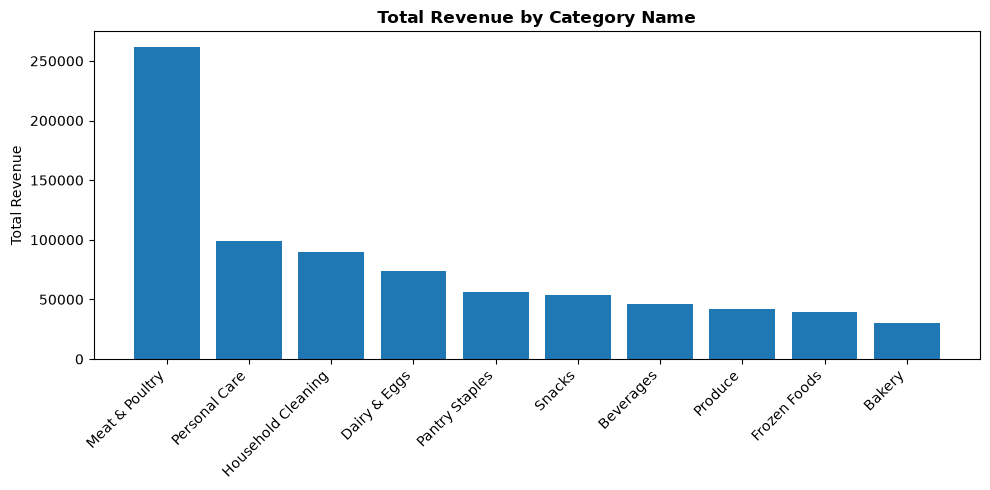

In [82]:
# For visualization we import matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(category_revenue['CategoryName'], category_revenue['TotalRevenue'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Category Name', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Meat & Poultry were over every other category - visually confirms  

### How it connects to top spenders:  

These are two different "slices" of the same underlying data (order_details), just grouped differently:  

- This chart = grouped by CategoryName -> shows what sells best overall
- Top spenders table = grouped by CustomerID -> shows who spends the most overall

They're not directly linked yet - you don't know if the top spender (CSTMR0127) actually bought Meat&Poultry specifically. To connect them, we'd need a new query grouping by both category AND customer.  

### See what CSTMR0127(#1 spender) actually bought:

In [97]:
customers.head()

,CustomerID,Gender,Age,City,Region,CustomerSegment,SignUpDate
0,CSTMR0001,Male,29,Istanbul,Marmara,Standard,2020-04-13
1,CSTMR0002,Other,40,Istanbul,Marmara,Standard,2020-04-08
2,CSTMR0003,Female,36,Bursa,Marmara,Premium,2022-08-14
3,CSTMR0004,Male,18,Istanbul,Marmara,Premium,2022-03-26
4,CSTMR0005,Male,43,Izmir,Aegean,Premium,2021-04-04


In [99]:
query = """
SELECT 
    o.OrderID,
    o.OrderDate,
    p.ProductID,
    p.ProductName,
    cat.CategoryName,
    od.Quantity,
    od.UnitPrice,
    (od.Quantity * od.UnitPrice) AS TotalPaid
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN Order_details od ON o.OrderID = od.OrderID
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
WHERE c.CustomerID = 'CSTMR0127'
ORDER BY TotalPaid DESC
LIMIT 5;
"""
pd.read_sql(query, conn)

,OrderID,OrderDate,ProductID,ProductName,CategoryName,Quantity,UnitPrice,TotalPaid
0,ORD07978,2023-03-02,PRDCT0005,XYZ's Atlantic Salmon,Meat & Poultry,22,30.29,666.38
1,ORD09150,2026-03-05,PRDCT0010,ABC's Tuna Steak,Meat & Poultry,17,33.50,569.50
2,ORD07978,2023-03-02,PRDCT0010,ABC's Tuna Steak,Meat & Poultry,8,25.17,201.36
3,ORD09481,2024-03-17,PRDCT0002,XYZ's Chicken Breast,Meat & Poultry,5,37.67,188.35
4,ORD07978,2023-03-02,PRDCT0001,ABC's Beef Ribeye,Meat & Poultry,8,23.43,187.44


**Question:** Which city brings in the most total revenue?

In [ ]:
query = """
SELECT
    p.ProductID,
    p.ProductName,
    cat.CategoryName
FROM Products p
JOIN Categories cat ON p.CategoryID = cat.CategoryID
LIMIT 13, 10;
"""
pd.read_sql(query, conn)

In [100]:
import seaborn as sns

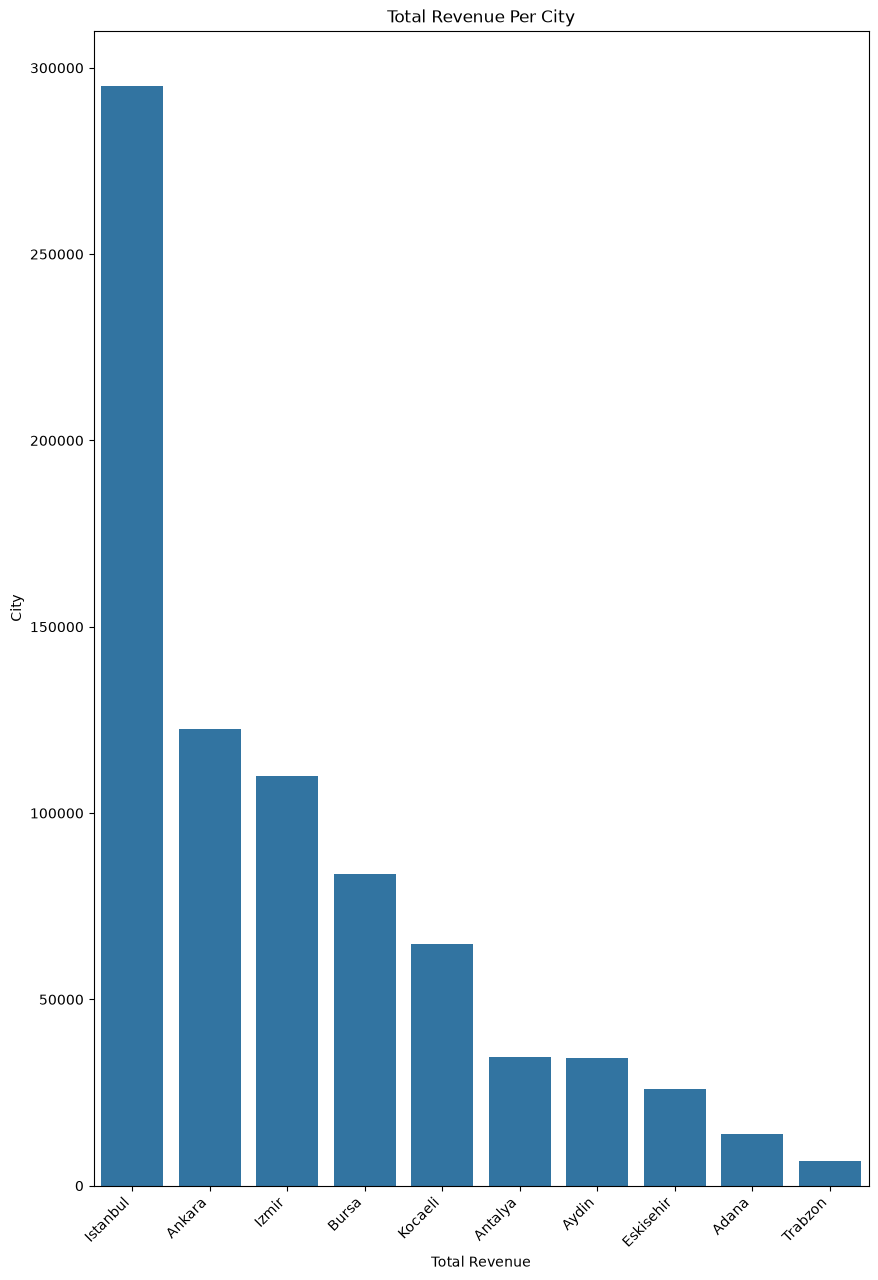

In [101]:
query = """
SELECT 
    c.City,
    SUM(od.Quantity * od.UnitPrice) AS TotalRevenue
FROM orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN Order_details od ON o.OrderID = od.OrderID
GROUP BY city
ORDER BY TotalRevenue DESC
"""
city_totalRevenue = pd.read_sql(query, conn)

plt.figure(figsize = (10, 15))
sns.barplot(data=city_totalRevenue, x='City', y='TotalRevenue')
plt.title('Total Revenue Per City')
plt.xlabel('Total Revenue')
plt.ylabel('City')
plt.xticks(rotation = 45, ha='right')
plt.tight_layout
plt.show()

**Answer:** From this plot I can easiy see the "Istabul" is the city with the higest revenue  

**One thing worth checking before desciding:** is Istanbul's highest revenue just because it has more customers, or because each customer there spends more? Those lead to different decisions.  

- Quick follow-up query -average revenue per customer, by city:

In [105]:
query = """
SELECT 
    c.City,
    COUNT(DISTINCT c.CustomerID) AS NumCustomers,
    SUM(od.Quantity * od.UnitPrice) AS TotalRevenue,
    SUM(od.Quantity * od.UnitPrice) / COUNT(DISTINCT c.CustomerID) AS RevenuePerCustomer
FROM orders o
JOIN order_details od ON o.OrderID = od.OrderID
JOIN customers c ON o.CustomerID = c.CustomerID
GROUP BY c.City
ORDER BY RevenuePerCustomer DESC;
"""
pd.read_sql(query, conn)

,City,NumCustomers,TotalRevenue,RevenuePerCustomer
0,Izmir,134,110061.00,821.350746
1,Adana,17,13931.13,819.478235
2,Eskisehir,32,26068.44,814.638750
3,Istanbul,364,295207.60,811.009890
4,Antalya,43,34548.93,803.463488
5,Ankara,155,122610.59,791.036065
6,Aydin,44,34339.56,780.444545
7,Bursa,111,83641.48,753.526847
8,Trabzon,9,6738.28,748.697778
9,Kocaeli,91,64785.46,711.928132


- We can see the **Istabul** the highest number of Customers and the highest Revenue but **Izmir** has the highest Revenue Per Customer.
- New piece: COUNT(DISTINCT c.CustomerID) — counts unique customers per city (not orders, actual people).

## Looking throught the data without asking any questions yet (getting farmiliar with the data)

In [ ]:
order_details.head(20)

- Do you see the same ProductID repeating a lot? Which one?
- Do you see any Quantity that looks unusually high or low?
- Do you see any DiscountRate that isn't 0?

In [ ]:
order_details['ProductID'].value_counts().head(10)
# What this literally does: counts how many times each ProductID appears in the table
# This alone tells you "which product shows up most in orders"

In [ ]:
order_details.shape

**What this tells us:** PRDCT0030 shows up 440 times across all order lines -> meaning it was bought (as line item) more often than any other product.  

**Qtn:** Does "appears most often" (440 times) necessarily mean "sold the most units"? -> Think about it - could a product appear in 440 different orders but each time someone only bought 1 unit, while another product appears in only 100 orders but someone buys 20 units each time?  

- value_counts() counts appearances (rows), not quantity sold. Those are genuinely different things, and mixing them up is a classic real-world mistake.

### Example that may click:  

- PRDCT0030 appears in 440 rows -> but maybe each row is just Quantity: 1 -> total sold = 440 units
- PRDCT0099 might appear in only 50 rows -> but each row is Quantity: 15 (bulk orders) -> total sold = 750 units

PRDCT0099 would never show up in your value_counts() top 10, even though it actually sold more units.

In [ ]:
order_details.groupby('ProductID')['Quantity'].sum().sort_values(ascending=False).head(10)

- What's different here: instead of counting rows, this adds up the Quantity column for each product - the real "how many units sold" number.
- **NOTICE:** 0025 and 0026 are new entries that weren't in the original top 10 at all - they must have lower row counts but higher quantitied per order (bulk buys). Meanwhile 0017 and 0012 dropped out of the top 10 entirely
- So the lesson holds true, just subtly: PRDCT0030 happens to win both ways this time (coincidence not guaranteed), but the ranking underneath it genuinely changed - proving row-count and quantity-sum are NOT the same measurements, exactly like you predicted.

- Next natural question, purely from curiosity, just think: Now that we know quantity != frequency, do you think revenue (money earned) will match either of these rankings, or could it be different again?
- **Think about it this way:** if PRDCT0030 sells 1415 units ad $2 each, that's $2,830 revenue. But if some other product only sells 200 units at $50 each, that's  $10,000 revenue - way more, despite far lower quantity.
- So the hypothesis (revenue tracks quantity) is only true if all products cost roughly the same. Do you know if that's true here? (look at UnitPrice variation across products).

In [ ]:
# Let's test the hypothesis directly
order_details.groupby('ProductID').apply(lambda x: (x['Quantity'] * x['UnitPrice']).sum()).sort_values(ascending=False).head(10)

- **What's new here:** apply (lambda x: ...) runs a custome calculation per group - for each ProductID, it multiplies Quantity * UnitPrice row-by-row, then sums it (same math as before, just written differently, per-product this time instead of per-category)